# 39 — Detection outputs and post-processing

An object detector usually produces many candidate boxes—often multiple overlapping predictions for the same object. Post-processing turns those raw candidates into a smaller set of useful detections.

In this notebook we will:

- interpret boxes, objectness, class probabilities, and confidence;
- remove weak candidates with a confidence threshold;
- understand why duplicate boxes remain;
- implement greedy non-maximum suppression (NMS);
- compare class-agnostic and class-wise NMS;
- visualize predictions before and after post-processing.

The candidates are synthetic so that each post-processing decision is easy to inspect.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

from cs231n_practice.detection import box_iou_aligned, pairwise_box_iou

np.set_printoptions(precision=3, suppress=True)
CLASS_NAMES = np.array(["cat", "dog"])

## 1. What a detector predicts

For each candidate, our simplified detector output contains:

```text
box:                 (x1, y1, x2, y2)
objectness:          probability that an object is present
class probabilities: conditional distribution over classes
```

We define the confidence for class $c$ as

$$s_c = P(\mathrm{object})P(c \mid \mathrm{object}).$$

The candidate label is the class with the largest class probability, and its final score is the corresponding class confidence. This factorization is useful for learning, although real detector heads differ: some produce logits, independent per-class scores, or no separate objectness output.

### Exercise 1 — Calculate labels and confidence scores

In [6]:
candidate_boxes = np.array([
    [10.0, 10.0, 55.0, 52.0],  # overlapping group at the left
    [12.0, 12.0, 56.0, 50.0],
    [11.0, 11.0, 54.0, 51.0],
    [68.0, 28.0, 110.0, 72.0], # overlapping group at the right
    [70.0, 30.0, 108.0, 70.0],
    [35.0, 5.0, 65.0, 30.0],   # weak isolated candidate
])
objectness = np.array([0.95, 0.90, 0.75, 0.85, 0.65, 0.40])
class_probabilities = np.array([
    [0.90, 0.10],
    [0.85, 0.15],
    [0.10, 0.90],
    [0.20, 0.80],
    [0.10, 0.90],
    [0.80, 0.20],
])

# multiply objectness by every candidate's class probabilities.
class_confidences = objectness[:, np.newaxis] * class_probabilities
# choose one class index and its confidence for every candidate.
candidate_labels = np.argmax(class_confidences, axis=1)
candidate_scores = np.max(class_confidences, axis=1)

assert class_confidences.shape == (6, 2)
np.testing.assert_array_equal(candidate_labels, [0, 0, 1, 1, 1, 0])
np.testing.assert_allclose(candidate_scores, [0.855, 0.765, 0.675, 0.680, 0.585, 0.320])
for index in range(len(candidate_boxes)):
    print(index, CLASS_NAMES[candidate_labels[index]], f"{candidate_scores[index]:.3f}")

0 cat 0.855
1 cat 0.765
2 dog 0.675
3 dog 0.680
4 dog 0.585
5 cat 0.320


## 2. Confidence thresholding

A confidence threshold removes candidates that are too uncertain to report. A higher threshold usually reduces false positives but may also remove real objects, lowering recall. It does not remove duplicates: two highly confident, overlapping candidates can both survive.

### Exercise 2 — Keep candidates with score at least 0.5

Use one Boolean mask to filter boxes, scores, and labels together. Keeping these arrays aligned is essential: row $i$ in each filtered array must still describe the same candidate.

In [58]:
confidence_threshold = 0.5

# create one mask and apply it to all candidate attributes.
confident = candidate_scores >= confidence_threshold
filtered_boxes = candidate_boxes[confident]
filtered_scores = candidate_scores[confident]
filtered_labels = candidate_labels[confident]

np.testing.assert_array_equal(confident, [True, True, True, True, True, False])
assert filtered_boxes.shape == (5, 4)
assert filtered_scores.shape == filtered_labels.shape == (5,)
print("Candidates before / after threshold:", len(candidate_boxes), len(filtered_boxes))

Candidates before / after threshold: 6 5


## 3. Find duplicate spatial predictions

Candidates from nearby grid locations or anchors may describe the same object. Large IoU is evidence that two boxes are spatial duplicates, although class labels also matter.

### Exercise 3 — Inspect candidate-to-candidate IoU

Calculate the square pairwise IoU matrix. Ignore its diagonal when finding the most-overlapping distinct pair, because every box has IoU 1 with itself.

In [ ]:
# calculate all pairwise IoUs among filtered_boxes.
candidate_ious = pairwise_box_iou(filtered_boxes, filtered_boxes)
assert candidate_ious.shape == (5, 5)
np.testing.assert_allclose(np.diag(candidate_ious), 1.0)

# replace the diagonal with a value that cannot become the maximum.
off_diagonal_ious = candidate_ious.copy()
off_diagonal_ious[np.diag_indices_from(off_diagonal_ious)] = -1.0
most_overlapping_pair = np.unravel_index(
    np.argmax(off_diagonal_ious), off_diagonal_ious.shape
)
assert set(most_overlapping_pair) == {0, 2}
print("Most-overlapping distinct pair:", most_overlapping_pair)
print("IoU:", off_diagonal_ious[most_overlapping_pair])
print("Labels:", CLASS_NAMES[filtered_labels[list(most_overlapping_pair)]])

Most-overlapping distinct pair: (np.int64(0), np.int64(2))
IoU: 0.91005291005291
Labels: ['cat' 'dog']


## 4. Greedy non-maximum suppression

NMS keeps a high-scoring box and suppresses lower-scoring boxes that overlap it too strongly:

1. sort candidates from highest to lowest score;
2. keep the highest-scoring remaining candidate;
3. calculate its IoU with all lower-scoring candidates;
4. remove candidates whose IoU is greater than the threshold;
5. repeat until no candidates remain.

The word **maximum** refers to keeping a local score maximum; **suppression** means discarding nearby lower-scoring alternatives. NMS does not average or adjust box coordinates.

We use `IoU > threshold` as the suppression rule. A box whose IoU equals the threshold is retained. Implementations may choose `>=`, so the boundary convention should be documented.

### Exercise 4 — Implement class-agnostic NMS

Return original indices in descending selection order. Class-agnostic means that overlap can suppress a candidate even when its predicted class differs.

In [59]:
def non_maximum_suppression(boxes, scores, iou_threshold):
    """Return kept indices in descending score-selection order."""
    boxes = np.asarray(boxes)
    scores = np.asarray(scores)
    # sort candidate indices from highest to lowest score.
    remaining = np.argsort(-scores)
    kept = []

    while remaining.size > 0:
        # keep the current highest-scoring index.
        current = remaining[0]
        kept.append(current)
        if remaining.size == 1:
            break

        other_indices = remaining[1:]
        # compare current with every other remaining box.
        overlaps = box_iou_aligned(boxes[current], boxes[other_indices])
        # retain only boxes not suppressed by the IoU rule.
        remaining = other_indices[overlaps <= iou_threshold]

    return np.asarray(kept, dtype=np.int64)

class_agnostic_keep = non_maximum_suppression(
    filtered_boxes, filtered_scores, iou_threshold=0.5
)
np.testing.assert_array_equal(class_agnostic_keep, [0, 3])
print("Class-agnostic kept indices:", class_agnostic_keep)
print("Kept labels:", CLASS_NAMES[filtered_labels[class_agnostic_keep]])

Class-agnostic kept indices: [0 3]
Kept labels: ['cat' 'dog']


In [46]:
(
    np.sort(-filtered_scores),
    np.sort(filtered_scores),
    np.argsort(-filtered_scores),
    np.argsort(filtered_scores)
)


(array([-0.855, -0.765, -0.68 , -0.675, -0.585]),
 array([0.585, 0.675, 0.68 , 0.765, 0.855]),
 array([0, 1, 3, 2, 4]),
 array([4, 2, 3, 1, 0]))

## 5. Class-wise NMS

Class-agnostic NMS treats two strongly overlapping boxes as duplicates regardless of their labels. This can be undesirable when different objects or categories overlap. Class-wise NMS separates candidates by predicted class and performs NMS inside each group.

In our synthetic candidates, filtered boxes 0 and 2 overlap strongly but predict `cat` and `dog`. Class-agnostic NMS removes box 2; class-wise NMS may retain both.

### Exercise 5 — Apply NMS independently per class

Local NMS indices refer to positions inside one class subset. Map them back through `class_indices` before combining the results. Finally, sort all retained original indices by their scores so the output order is deterministic.

In [50]:
def classwise_non_maximum_suppression(
    boxes, scores, labels, iou_threshold
):
    """Run NMS independently for every predicted class."""
    boxes = np.asarray(boxes)
    scores = np.asarray(scores)
    labels = np.asarray(labels)
    kept = []

    for class_index in np.unique(labels):
        # find original indices belonging to this class.
        class_indices = np.where(labels == class_index)[0]
        local_keep = non_maximum_suppression(
            boxes[class_indices], scores[class_indices], iou_threshold
        )
        # map local indices back to original filtered-array indices.
        kept.extend(class_indices[local_keep])

    kept = np.asarray(kept, dtype=np.int64)
    # return retained indices in descending score order.
    return kept[np.argsort(-scores[kept])]

classwise_keep = classwise_non_maximum_suppression(
    filtered_boxes, filtered_scores, filtered_labels, iou_threshold=0.5
)
np.testing.assert_array_equal(classwise_keep, [0, 3, 2])
print("Class-wise kept indices:", classwise_keep)
print("Kept labels:", CLASS_NAMES[filtered_labels[classwise_keep]])

Class-wise kept indices: [0 3 2]
Kept labels: ['cat' 'dog' 'dog']


In [48]:
(
    np.where(filtered_labels == 0),
    np.where(filtered_labels == 1),
)

((array([0, 1]),), (array([2, 3, 4]),))

## 6. Visualize the post-processing stages

A visualization makes the behavioral difference clear: thresholding removes weak candidates, while NMS removes spatial duplicates. Class-wise NMS retains overlapping boxes of different predicted classes.

### Exercise 6 — Draw candidates before and after class-wise NMS

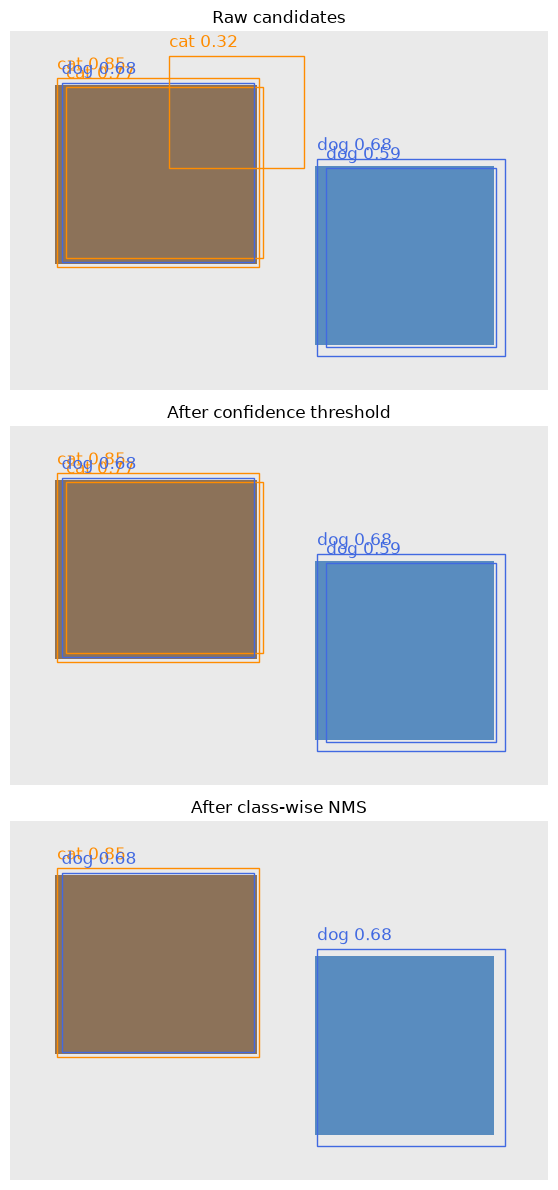

In [55]:
image_height, image_width = 80, 120
image = np.full((image_height, image_width, 3), 0.92)
image[12:52, 10:55] = [0.55, 0.45, 0.35]
image[30:70, 68:108] = [0.35, 0.55, 0.75]
CLASS_COLORS = np.array(["darkorange", "royalblue"])

def draw_detections(axis, image, boxes, scores, labels, title):
    axis.imshow(image)
    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box
        color = CLASS_COLORS[label]
        # draw the corner-format box and a class/score label.
        axis.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=color, linewidth=1))
        axis.text(x1, y1 - 2, f"{CLASS_NAMES[label]} {score:.2f}", color=color, fontsize=12, weight="light")
    axis.set_title(title)
    axis.axis("off")

fig, axes = plt.subplots(3, 1, figsize=(8, 12))
draw_detections(
    axes[0], image, candidate_boxes, candidate_scores, candidate_labels,
    "Raw candidates",
)
draw_detections(
    axes[1], image, filtered_boxes, filtered_scores, filtered_labels,
    "After confidence threshold",
)
draw_detections(
    axes[2], image, filtered_boxes[classwise_keep],
    filtered_scores[classwise_keep], filtered_labels[classwise_keep],
    "After class-wise NMS",
)
plt.tight_layout()
plt.show()

## 7. What NMS does not solve

NMS is a local greedy rule, not a learned understanding of object identity. Its result depends on confidence ordering and the chosen IoU threshold. A threshold that is too low may suppress nearby distinct objects; one that is too high may leave duplicates. Standard NMS also discards boxes abruptly. Variants such as Soft-NMS reduce scores instead, but the basic trade-off remains.

Post-processing cannot repair fundamentally poor box coordinates or class scores. In [the next notebook](./40_detection_evaluation.ipynb), detection evaluation will decide which retained predictions count as true positives and false positives.

## Reflection

Answer briefly in your own words.

1. What is the difference between objectness, class probability, and final class confidence?
2. Why must the same threshold mask be applied to boxes, labels, and scores?
3. Why does confidence thresholding not remove duplicate predictions?
4. Why does greedy NMS process boxes in descending score order?
5. What does the IoU threshold control in NMS?
6. Why did class-agnostic NMS remove filtered box 2?
7. Why did class-wise NMS retain both filtered boxes 0 and 2?
8. What can go wrong when the NMS threshold is too low or too high?
9. Why is NMS output not yet enough to calculate detector accuracy?

### Answers

1. Objectness estimates whether a candidate contains any object. The class probabilities describe which class it belongs to, conditional on an object being present. The final class confidence combines both quantities.
2. to remain consistent data, if we filter scores we need only boxes and labels of those filtered ones. The arrays describe the same candidates row by row. Applying different masks would separate a box from its corresponding score or label.
3. it does not check boundary boxes details. Confidence thresholding evaluates every candidate independently. It does not compare box coordinates or IoU between candidates, so several highly confident boxes around the same object can all survive.
4. it remain top scored box and removes all similar to it that have lower score so we have to start from top one and compare it with each lower. NMS assumes the highest-scoring box is the best representative of an object, keeps it, and removes lower-scoring boxes that overlap it too strongly.
5. what boxes will be removed in case they are similare to the ones that have greater confidence level. The IoU threshold controls how much overlap is tolerated. With the notebook’s rule, a lower-scoring box is suppressed when its IoU with a kept box is greater than the threshold.
6. it is similar to 0 but has a bit less confidence level. Box 0 is selected first because it has the higher score. Box 2 has IoU approximately 0.91 with box 0, which exceeds the 0.5 threshold, so class-agnostic NMS suppresses it.
7. they have different class labels. Boxes 0 and 2 have different predicted classes, so they are processed in separate NMS groups and cannot suppress each other.
8. too low - too many boxes are discarted, too high - too many duplicates remain. A low threshold may suppress distinct nearby objects. A high threshold may retain multiple predictions of the same object.
9. NMS is post-processing technique but not detection itself. to calculate accuracy we need true boundary boxes and labels. NMS only post-processes predictions. Evaluation additionally needs ground-truth boxes and labels, a matching procedure, an IoU criterion, and rules for counting true positives, false positives, and false negatives.